In [1]:
import pandas as pd
import numpy as np
# import plotly.express as px
# import plotly.graph_objects as go
# import matplotlib.colors as mcolors
# from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import seaborn as sns
# import scipy
# pd.set_option('display.max_columns', None)

# from itertools import combinations
from statannotations.Annotator import Annotator
# from sklearn.preprocessing import StandardScaler
# # import linear regression
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import train_test_split
# from sklearn.feature_selection import RFE
# from sklearn.model_selection import cross_val_score
# from sklearn.model_selection import KFold
# # import LogisticRegression
# from sklearn.linear_model import LogisticRegression
# # import confusion_matrix
# from sklearn.metrics import confusion_matrix
# # import lasso
# from sklearn.linear_model import Lasso
# from sklearn.metrics import r2_score
# import statsmodels.api as sm


def read_fasta(fasta_file):
    with open(fasta_file) as f:
        lines = f.readlines()
    newID = [x.strip() for x in lines[::2]]
    sequences = [x.strip() for x in lines[1::2]]
    # remove the '>' from the names
    newID = [x[1:] for x in newID]
    return pd.DataFrame({'newID':newID, 'sequence':sequences}).set_index('newID')

def write_fasta(df, fasta_file):
    with open(fasta_file, 'w') as f:
        # use columns '#name' and 'sequence' as header and sequence
        for index, row in df.iterrows():
            f.write('>' + str(index) + '\n')
            f.write(row['sequence'] + '\n')



## ProReg data

### Pre-process

In [2]:
def preprocessMPRA(data_file, map_file, seq_file, cell_type, rep = 3):
    mpra_data = pd.read_csv(data_file, sep='\t', index_col='name')
    mpra_data.index.rename("newID", inplace=True)
    # only keep rows with at least 3 replicates
    mpra_data = mpra_data[mpra_data['replicates'] >= rep]
    print(mpra_data.shape)

    # map of sequence with IDs and oligo IDs
    oligomap = pd.read_csv(map_file, sep='\t', index_col='newID')
    print(oligomap.shape)

    # map to sequences
    seqs = read_fasta(seq_file)

    # merge the two dataframes on index, keep inner
    df_design = pd.merge(mpra_data, oligomap, left_index=True, right_index=True, how='inner')

    df_ = df_design[['#name','sequence', 'Label', 'log2']].copy()
    cell_ = 'log2_' + cell_type
    df_.rename(columns={'log2':cell_}, inplace=True)
    print(df_.shape)

    return df_

In [3]:
# hepg2 = preprocessMPRA('/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/experiments/second_approach/mprasnakeflow/results/experiments/run1+2+3HepG2_original/assigned_counts/standardRun1+2+3/standard/HepG2_allreps_minThreshold_merged.combined.tsv.gz', '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/design/final_design/design_probes_newIDs.tsv.gz', '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/experiments/first_approach/assignment_run2/reference/reference.fa', 'HepG2', 3)
# hepg2.head()

In [4]:
# hek = preprocessMPRA('/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/experiments/second_approach/mprasnakeflow/results/experiments/run3+4+5+6/assigned_counts/standardRun1+2+3/standard/HEK293T_allreps_minThreshold_merged.combined.tsv.gz', '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/design/final_design/design_probes_newIDs.tsv.gz', '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/experiments/first_approach/assignment_run2/reference/reference.fa', 'HEK293T', 3)
# hek.head()

In [5]:
# # merge the two dataframes on index, #name, sequence, Label
# mpra = pd.merge(hepg2, hek, on=['#name', 'sequence', 'Label', 'newID'], how='inner')
# mpra.head()

In [6]:
# # save as tsv.gz
# mpra.to_csv('/data/gpfs-1/users/dashpm_c/work/projects/gene_expression_mpra/data/proreg_log2.tsv.gz', sep='\t', compression='gzip')

In [7]:
# read tsv file
mpra = pd.read_csv('/home/kisa/coding/80K_MPRA/80K-Analysis/02_controls/mohan_results/proreg_log2.tsv.gz', sep='\t')
mpra.head()

,newID,#name,sequence,Label,log2_HepG2,log2_HEK293T
0,oligo_000002,C:chr3:110657652-110657851(+)_FOXA1_FOXA2-NoMo...,AGGACCGGATCAACTCAAGGAAATACTAGTGAATGTCAGTATTTGA...,liverMPRA_(+),0.872232,-0.279740
1,oligo_000003,C:chr10:129955318-129955517(+)_FOXA1-ChMod_chr...,AGGACCGGATCAACTTACTCCCTCCCCATGCTCAGCCTGTTTTCCG...,liverMPRA_(+),1.586642,-0.153570
2,oligo_000004,C:chr2:135849337-135849536(+)_HNF4A-NoMod_chr2...,AGGACCGGATCAACTGGTACTCAATAAATGGTGTCTATAATTGTTA...,liverMPRA_(+),-0.093814,-0.955967
3,oligo_000005,C:chr20:54933686-54933885(+)_EP300-NoMod_chr20...,AGGACCGGATCAACTCCACGGCCCTACGCCCACCTTTGTGCCCGCA...,liverMPRA_(+),0.551150,0.635787
4,oligo_000006,C:chr6:1335679-1335878(+)_FOXA1_FOXA2-ChMod_ch...,AGGACCGGATCAACTAAAATATTCTGCTACTACTCGACAGTTTAAA...,liverMPRA_(+),0.381982,-0.118496


## Sanity check

In [8]:
# for all values in #name in merged, extract string between pos 2 and first occurence of (
mpra['Prediction_region'] = mpra['#name'].str[2:-4]
# keep first after splitting at first "("
mpra['Prediction_region'] = mpra['Prediction_region'].str.split("(").str[0]
# replace all ":" in "-" in Prediction_region
mpra['Prediction_region'] = mpra['Prediction_region'].str.replace(":", "-")

# get strand value bewteen '(' and ')'
mpra['strand'] = mpra['#name'].str.split("(").str[1]
mpra['strand'] = mpra['strand'].str.split(")").str[0]
mpra.head()

,newID,#name,sequence,Label,log2_HepG2,log2_HEK293T,Prediction_region,strand
0,oligo_000002,C:chr3:110657652-110657851(+)_FOXA1_FOXA2-NoMo...,AGGACCGGATCAACTCAAGGAAATACTAGTGAATGTCAGTATTTGA...,liverMPRA_(+),0.872232,-0.279740,chr3-110657652-110657851,+
1,oligo_000003,C:chr10:129955318-129955517(+)_FOXA1-ChMod_chr...,AGGACCGGATCAACTTACTCCCTCCCCATGCTCAGCCTGTTTTCCG...,liverMPRA_(+),1.586642,-0.153570,chr10-129955318-129955517,+
2,oligo_000004,C:chr2:135849337-135849536(+)_HNF4A-NoMod_chr2...,AGGACCGGATCAACTGGTACTCAATAAATGGTGTCTATAATTGTTA...,liverMPRA_(+),-0.093814,-0.955967,chr2-135849337-135849536,+
3,oligo_000005,C:chr20:54933686-54933885(+)_EP300-NoMod_chr20...,AGGACCGGATCAACTCCACGGCCCTACGCCCACCTTTGTGCCCGCA...,liverMPRA_(+),0.551150,0.635787,chr20-54933686-54933885,+
4,oligo_000006,C:chr6:1335679-1335878(+)_FOXA1_FOXA2-ChMod_ch...,AGGACCGGATCAACTAAAATATTCTGCTACTACTCGACAGTTTAAA...,liverMPRA_(+),0.381982,-0.118496,chr6-1335679-1335878,+


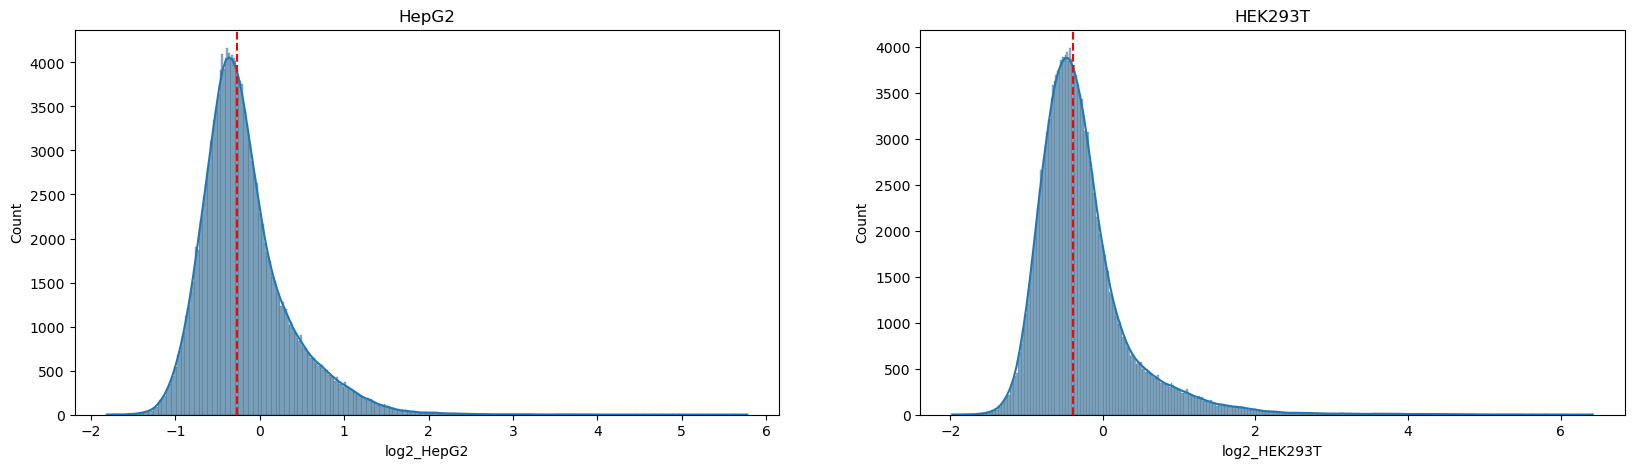

In [9]:
# plot distribution of log2 values for HepG2 and HEK293T
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(mpra['log2_HepG2'], ax=ax[0], kde=True)
ax[0].set_title('HepG2')
sns.histplot(mpra['log2_HEK293T'], ax=ax[1], kde=True)
ax[1].set_title('HEK293T')

# draw a vertical line at median log2
ax[0].axvline(mpra['log2_HepG2'].median(), color='r', linestyle='--')
ax[1].axvline(mpra['log2_HEK293T'].median(), color='r', linestyle='--')
plt.show()

## Controls

In [10]:
# print all Labels
mpra['Label'].unique()

array(['liverMPRA_(+)', 'liverMPRA_controls', 'liverMPRA_(-)',
       'liverMPRA_inBetween', 'DNAse_(-)_blood', 'DNAse_(-)_brain',
       'DNAse_(+)', 'HAR_(-)', 'HAR_(+)', 'SatMut_all',
       'BasVanStansel_all', 'ProximalPromoterDesign'], dtype=object)

In [11]:
# merge 'DNAse_(-)_blood', 'DNAse_(-)_brain' as 1 'DNase_(-)
mpra['Label'] = mpra['Label'].replace(['DNAse_(-)_blood', 'DNAse_(-)_brain'], 'DNase (-)')
# rename DNAse_(+) to DNase_(+)
mpra['Label'] = mpra['Label'].replace('DNAse_(+)', 'DNase (+)')
# rename ProximalPromoterDesign to Test_cCREs
mpra['Label'] = mpra['Label'].replace('ProximalPromoterDesign', 'Test cCREs')
# rename liverMPRA_(+) to liverMPRA (+)
mpra['Label'] = mpra['Label'].replace('liverMPRA_(+)', 'liverMPRA (+)')
# rename liverMPRA_(-) to liverMPRA (-)
mpra['Label'] = mpra['Label'].replace('liverMPRA_(-)', 'liverMPRA (-)')

In [12]:
# print all Labels
mpra['Label'].unique()

array(['liverMPRA (+)', 'liverMPRA_controls', 'liverMPRA (-)',
       'liverMPRA_inBetween', 'DNase (-)', 'DNase (+)', 'HAR_(-)',
       'HAR_(+)', 'SatMut_all', 'BasVanStansel_all', 'Test cCREs'],
      dtype=object)

In [13]:
# remove rows with labels not in ['liverMPRA_(+)' 'liverMPRA_(-)' 'DNAse_(-)_blood' 'DNAse_(-)_brain' 'DNAse_(+)' 'ProximalPromoterDesign']
mpra2 = mpra[mpra['Label'].isin(['liverMPRA (+)', 'liverMPRA (-)', 'DNase (-)', 'DNase (+)', 'Test cCREs'])]

In [14]:
pairs = [('liverMPRA (+)', 'liverMPRA (-)'), ('DNase (+)', 'DNase (-)')]

### normalize by negative control

In [15]:
# use mean log2 of DNase (-) as baseline, and normalize log2 values of other values
mpra['log2_HepG2'] = mpra['log2_HepG2'] - mpra2[mpra2['Label'] == 'DNase (-)']['log2_HepG2'].mean()
mpra['log2_HEK293T'] = mpra['log2_HEK293T'] - mpra2[mpra2['Label'] == 'DNase (-)']['log2_HEK293T'].mean()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

liverMPRA (+) vs. liverMPRA (-): Mann-Whitney-Wilcoxon test two-sided, P_val:2.308e-40 U_stat=1.528e+05
DNase (+) vs. DNase (-): Mann-Whitney-Wilcoxon test two-sided, P_val:1.318e-04 U_stat=7.870e+02


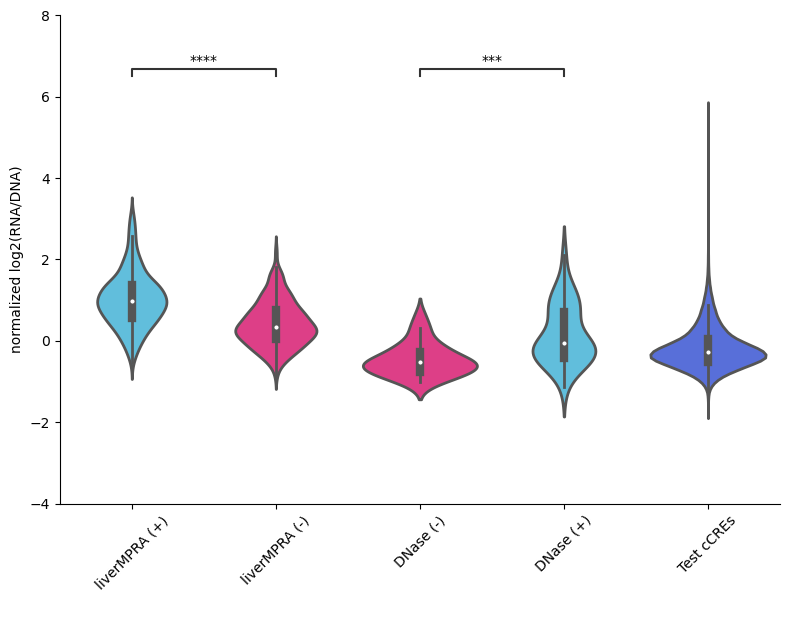

In [16]:
# plot a violin plot for each label against log2_HepG2, make liverMPRA_(+) and DNase_(+) as one color and liverMPRA_(-) and DNase_(-) as another color and test cCREs as another color
fig, ax = plt.subplots(figsize=(8,6))
# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x='Label', y='log2_HepG2', data=mpra2, ax=ax, color='white', inner='box', linewidth=2, palette={'liverMPRA (+)': '#4CC9F0', 'liverMPRA (-)': '#F72585', 'DNase (+)': '#4CC9F0', 'DNase (-)': '#F72585', 'Test cCREs': '#4361EE'}, linecolor='white')
annotator = Annotator(ax, pairs, data=mpra2, x="Label",y='log2_HepG2', order=['liverMPRA (+)', 'liverMPRA (-)', 'DNase (+)', 'DNase (-)',  'Test cCREs'])
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

# increase font size
plt.rcParams.update({'font.size': 20})
# increase y axis limit
plt.ylim(-4, 8)
# save plot as png, 600dpi
# plt.savefig('hek_controls_2.svg', dpi=600, bbox_inches='tight')
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

liverMPRA (+) vs. liverMPRA (-): Mann-Whitney-Wilcoxon test two-sided, P_val:2.879e-24 U_stat=1.406e+05
DNase (+) vs. DNase (-): Mann-Whitney-Wilcoxon test two-sided, P_val:1.430e-02 U_stat=6.855e+02


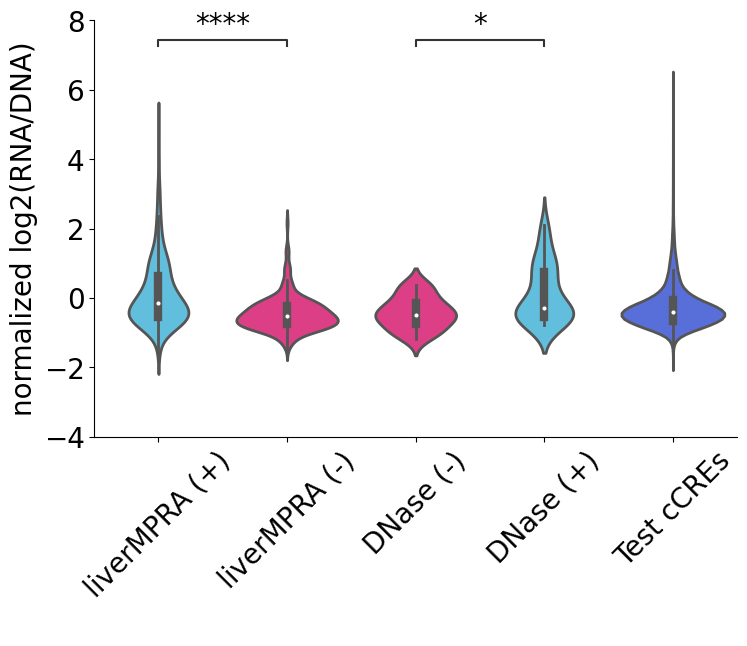

In [17]:
# plot a violin plot for each label against log2_HepG2, make liverMPRA_(+) and DNase_(+) as one color and liverMPRA_(-) and DNase_(-) as another color and test cCREs as another color
fig, ax = plt.subplots(figsize=(8,6))
# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x='Label', y='log2_HEK293T', data=mpra2, ax=ax, color='white', inner='box', linewidth=2, palette={'liverMPRA (+)': '#4CC9F0', 'liverMPRA (-)': '#F72585', 'DNase (+)': '#4CC9F0', 'DNase (-)': '#F72585', 'Test cCREs': '#4361EE'}, linecolor='white')
annotator = Annotator(ax, pairs, data=mpra2, x="Label",y='log2_HEK293T', order=['liverMPRA (+)', 'liverMPRA (-)', 'DNase (+)', 'DNase (-)',  'Test cCREs'])
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

# increase font size
plt.rcParams.update({'font.size': 20})
# increase y axis limit
plt.ylim(-4, 8)
# save plot as png, 600dpi
# plt.savefig('hek_controls_2.svg', dpi=600, bbox_inches='tight')
plt.show()

### Investigate DNase + for "universal" positive controls
- filtering for DNase + 
- how many do we have? - 36
- check if top part is similar within both groups (set of both and check for the overlap)

Pearson correlation coefficient: 0.9108


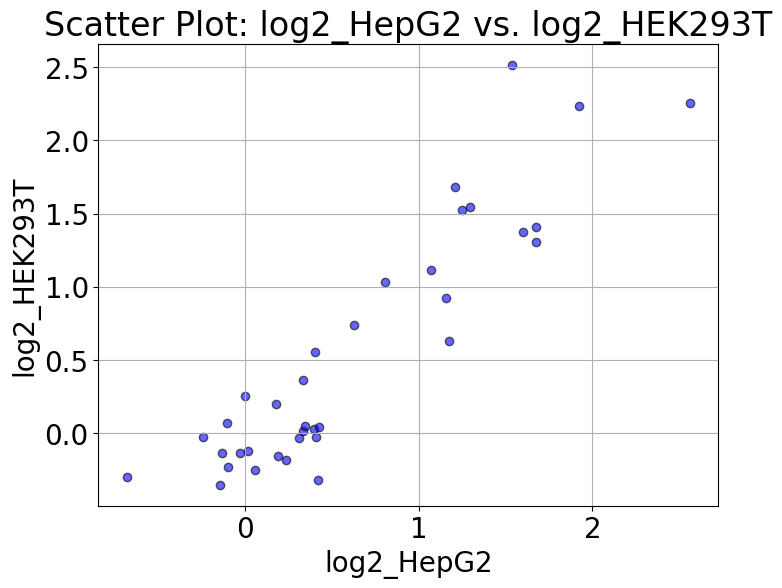

Pearson correlation coefficient: 0.9108


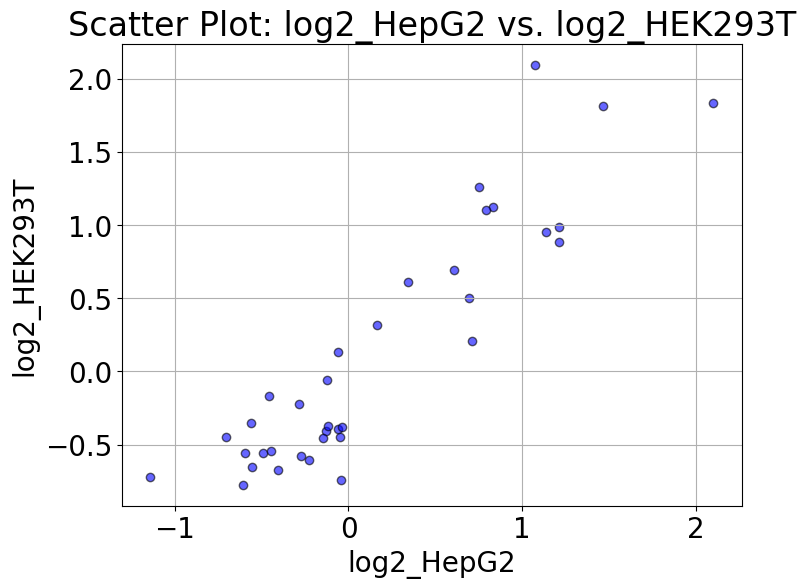

In [32]:
# check correlation with and without normalization

correlation = mpra_dnase_plus['log2_HepG2'].corr(mpra_dnase_plus['log2_HEK293T'])

print(f"Pearson correlation coefficient: {correlation:.4f}")
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(8, 6))
plt.scatter(mpra_dnase_plus['log2_HepG2'], mpra_dnase_plus['log2_HEK293T'], alpha=0.6, color='b', edgecolors='k')
plt.xlabel('log2_HepG2')
plt.ylabel('log2_HEK293T')
plt.title('Scatter Plot: log2_HepG2 vs. log2_HEK293T')
plt.grid(True)
plt.show()

# without normalization
mpra_dnase_plus_not_normalized = mpra2[mpra2['Label'].isin(['DNase (+)'])]

correlation = mpra_dnase_plus_not_normalized['log2_HepG2'].corr(mpra_dnase_plus_not_normalized['log2_HEK293T'])

print(f"Pearson correlation coefficient: {correlation:.4f}")
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(8, 6))
plt.scatter(mpra_dnase_plus_not_normalized['log2_HepG2'], mpra_dnase_plus_not_normalized['log2_HEK293T'], alpha=0.6, color='b', edgecolors='k')
plt.xlabel('log2_HepG2')
plt.ylabel('log2_HEK293T')
plt.title('Scatter Plot: log2_HepG2 vs. log2_HEK293T')
plt.grid(True)
plt.show()

In [33]:
mpra_dnase_plus = mpra[mpra['Label'].isin(['DNase (+)'])]
mpra_dnase_plus.shape # (36, 8)

top_number = 9

# top log2_HepG2
top_HepG2 = mpra_dnase_plus.sort_values(by='log2_HepG2', ascending=False).head(top_number)
print(f"Min hepG2 log2 value: {top_HepG2['log2_HepG2'].min()}")
# top log2_HEK293T
top_HEK293T = mpra_dnase_plus.sort_values(by='log2_HEK293T', ascending=False).head(top_number)
print(f"Min log2_HEK293T value: {top_HEK293T['log2_HEK293T'].min()}")

# investigate the names
set_HepG2 = set(top_HepG2['#name'])
set_HEK293T = set(top_HEK293T['#name'])

# check overlap
common_names = set_HepG2 & set_HEK293T # 9/10 overlap
print(f"Overlap: {round(len(common_names)/top_number,3)}, (#{len(common_names)})")

Min hepG2 log2 value: 1.210186378789246
Min log2_HEK293T value: 1.3091400326324143
Overlap: 1.0, (#9)


Pearson correlation coefficient: 0.4642


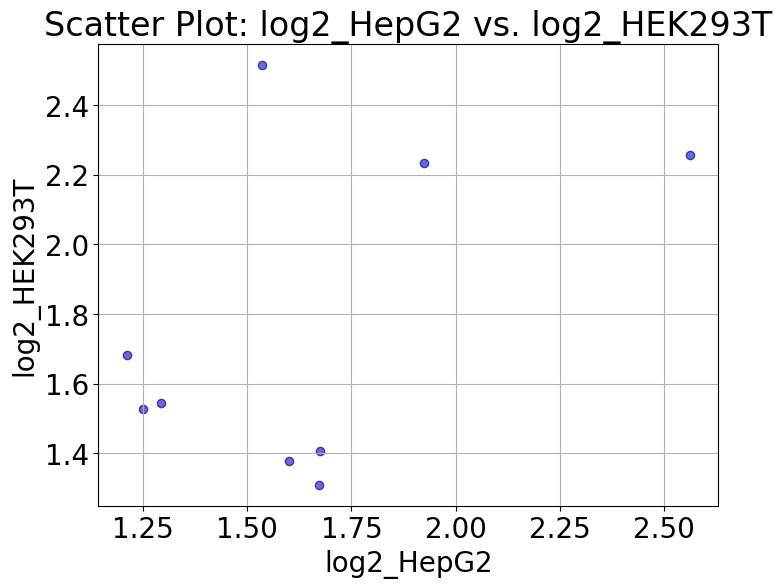

In [34]:
correlation = top_HEK293T['log2_HepG2'].corr(top_HEK293T['log2_HEK293T'])

print(f"Pearson correlation coefficient: {correlation:.4f}")
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(8, 6))
plt.scatter(top_HEK293T['log2_HepG2'], top_HEK293T['log2_HEK293T'], alpha=0.6, color='b', edgecolors='k')
plt.xlabel('log2_HepG2')
plt.ylabel('log2_HEK293T')
plt.title('Scatter Plot: log2_HepG2 vs. log2_HEK293T')
plt.grid(True)
plt.show()

Pearson correlation coefficient: 0.4642


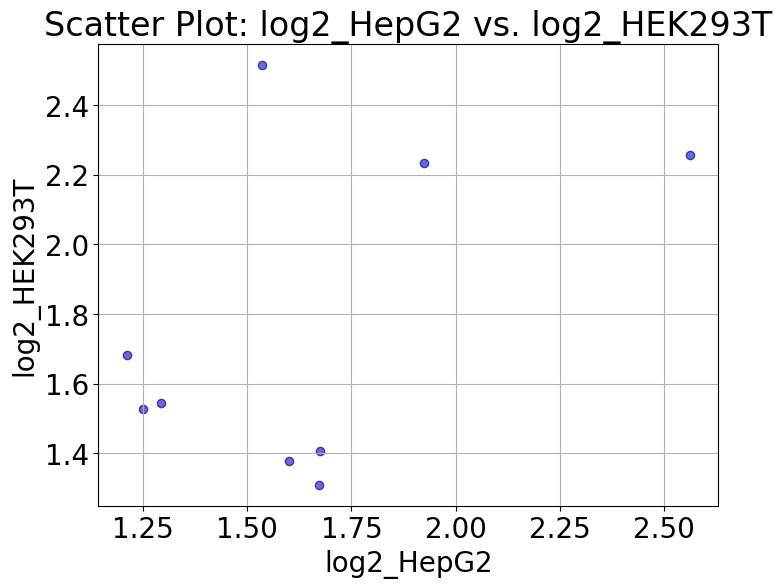

In [27]:
correlation = top_HepG2['log2_HepG2'].corr(top_HepG2['log2_HEK293T'])

print(f"Pearson correlation coefficient: {correlation:.4f}")
# Assuming your DataFrame is named 'df'
plt.figure(figsize=(8, 6))
plt.scatter(top_HepG2['log2_HepG2'], top_HepG2['log2_HEK293T'], alpha=0.6, color='b', edgecolors='k')
plt.xlabel('log2_HepG2')
plt.ylabel('log2_HEK293T')
plt.title('Scatter Plot: log2_HepG2 vs. log2_HEK293T')
plt.grid(True)
plt.show()


In [65]:
import pandas as pd

# Assuming your DataFrame is named 'df'
correlation = top_HepG2['log2_HepG2'].corr(top_HepG2['log2_HEK293T'])

print(f"Pearson correlation coefficient: {correlation:.4f}")


Pearson correlation coefficient: 0.4758


In [50]:
set_HepG2

{'C:chr12:58240762-58240961(+)_active_count:119:001',
 'C:chr14:50100991-50101190(+)_active_count:112:001',
 'C:chr16:284636-284835(+)_active_count:118:001',
 'C:chr19:10981770-10981969(+)_active_count:124:001',
 'C:chr22:38577809-38578008(+)_active_count:112:001',
 'C:chr5:218248-218447(+)_active_count:112:001',
 'C:chr5:71616039-71616238(+)_active_count:119:001',
 'C:chr7:102389211-102389410(+)_active_count:111:001',
 'C:chr7:6048735-6048934(+)_active_count:121:001',
 'C:chr8:8085453-8085652(+)_active_count:110:001'}

In [51]:
set_HEK293T

{'C:chr10:103815955-103816154(+)_active_count:110:001',
 'C:chr12:58240762-58240961(+)_active_count:119:001',
 'C:chr16:284636-284835(+)_active_count:118:001',
 'C:chr19:10981770-10981969(+)_active_count:124:001',
 'C:chr22:38577809-38578008(+)_active_count:112:001',
 'C:chr5:218248-218447(+)_active_count:112:001',
 'C:chr5:71616039-71616238(+)_active_count:119:001',
 'C:chr7:102389211-102389410(+)_active_count:111:001',
 'C:chr7:6048735-6048934(+)_active_count:121:001',
 'C:chr8:8085453-8085652(+)_active_count:110:001'}

In [52]:
common_names

{'C:chr12:58240762-58240961(+)_active_count:119:001',
 'C:chr16:284636-284835(+)_active_count:118:001',
 'C:chr19:10981770-10981969(+)_active_count:124:001',
 'C:chr22:38577809-38578008(+)_active_count:112:001',
 'C:chr5:218248-218447(+)_active_count:112:001',
 'C:chr5:71616039-71616238(+)_active_count:119:001',
 'C:chr7:102389211-102389410(+)_active_count:111:001',
 'C:chr7:6048735-6048934(+)_active_count:121:001',
 'C:chr8:8085453-8085652(+)_active_count:110:001'}

## pre-process  - open-chromatin

In [ ]:
# read

## make FIMO input

In [31]:
# write a function that takes in a dataframe with log2 array column as input, and number of sequences as top and bottom after absolute sorting of log2 values
def plot_top_bottom(df, cell_type, top=250, bottom=250):
    # sort by absolute log2 values
    df = df.reindex(df['log2_'+cell_type].abs().sort_values(ascending=False).index)

    # trim sequences by removing 15 bases from the start and end
    df['sequence'] = df['sequence'].str[15:-15]
    # take top and bottom
    top_df = df.head(top)
    bottom_df = df.tail(bottom)
    #
    write_fasta(top_df, '/data/gpfs-1/users/dashpm_c/work/projects/gene_expression_mpra/data/log2_'+cell_type+'_top_'+str(top)+'.fa')
    write_fasta(bottom_df, '/data/gpfs-1/users/dashpm_c/work/projects/gene_expression_mpra/data/log2_'+cell_type+'_bottom_'+str(bottom)+'.fa')

    return print("done!")

In [33]:
plot_top_bottom(mpra, 'HepG2', top=1000, bottom=1000)
plot_top_bottom(mpra, 'HEK293T', top=1000, bottom=1000)

done!
done!


## bed-like

## open-chromatin